In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.units import inch
import os

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv("time_series_covid19_confirmed_global.csv")
df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,209322,209340,209358,209362,209369,209390,209406,209436,209451,209451
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,334391,334408,334408,334427,334427,334427,334427,334427,334443,334457
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271441,271448,271463,271469,271469,271477,271477,271490,271494,271496
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47866,47875,47875,47875,47875,47875,47875,47875,47890,47890
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,105255,105277,105277,105277,105277,105277,105277,105277,105288,105288


In [4]:
df_country = df.drop(columns=["Province/State", "Lat", "Long"])
df_country = df_country.groupby("Country/Region").sum()
df_country.head()


df_country = df_country.T
df_country.index = pd.to_datetime(df_country.index)
df_country.head()

C:\Users\arthi\AppData\Local\Temp\ipykernel_3744\4091090194.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_country.index = pd.to_datetime(df_country.index)


Country/Region,Afghanistan,Albania,Algeria,Andorra,Angola,Antarctica,Antigua and Barbuda,Argentina,Armenia,Australia,...,Uruguay,Uzbekistan,Vanuatu,Venezuela,Vietnam,West Bank and Gaza,Winter Olympics 2022,Yemen,Zambia,Zimbabwe
2020-01-22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2020-01-23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-25,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
2020-01-26,0,0,0,0,0,0,0,0,0,4,...,0,0,0,0,2,0,0,0,0,0


In [5]:
countries = ["India", "US", "Brazil"]
covid = df_country[countries]

In [6]:
daily_cases = covid.diff().fillna(0)
daily_cases.head()

Country/Region,India,US,Brazil
2020-01-22,0.0,0.0,0.0
2020-01-23,0.0,0.0,0.0
2020-01-24,0.0,1.0,0.0
2020-01-25,0.0,0.0,0.0
2020-01-26,0.0,3.0,0.0


In [7]:
weekly_cases = daily_cases.resample("W").sum()
weekly_cases.head()

Country/Region,India,US,Brazil
2020-01-26,0.0,4.0,0.0
2020-02-02,2.0,3.0,0.0
2020-02-09,1.0,4.0,0.0
2020-02-16,0.0,2.0,0.0
2020-02-23,0.0,2.0,0.0


In [8]:
rolling_avg = daily_cases.rolling(window=7).mean()

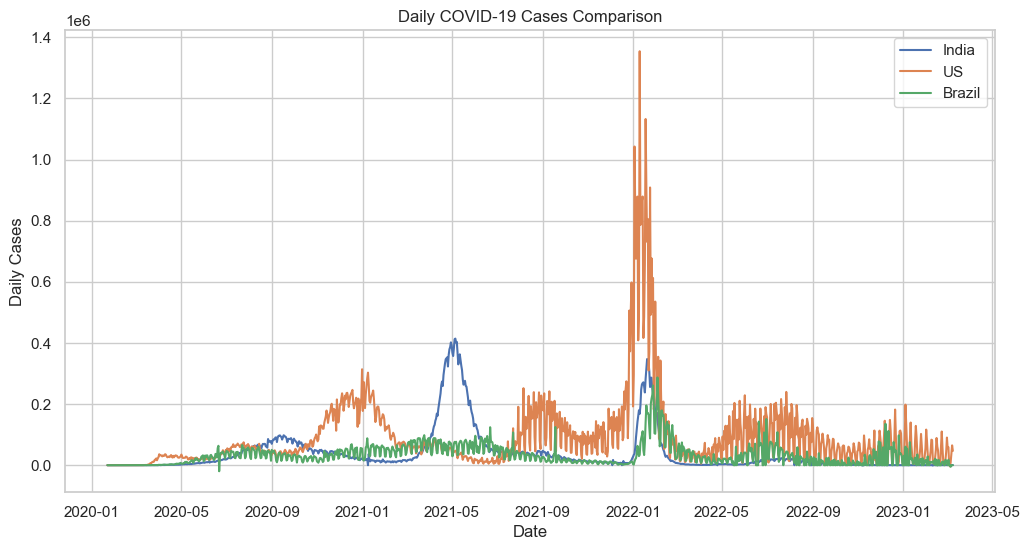

In [9]:
plt.figure(figsize=(12,6))
for country in countries:
    plt.plot(daily_cases.index, daily_cases[country], label=country)

plt.title("Daily COVID-19 Cases Comparison")
plt.xlabel("Date")
plt.ylabel("Daily Cases")
plt.legend()
plt.savefig("daily_cases_comparison.png")
plt.show()

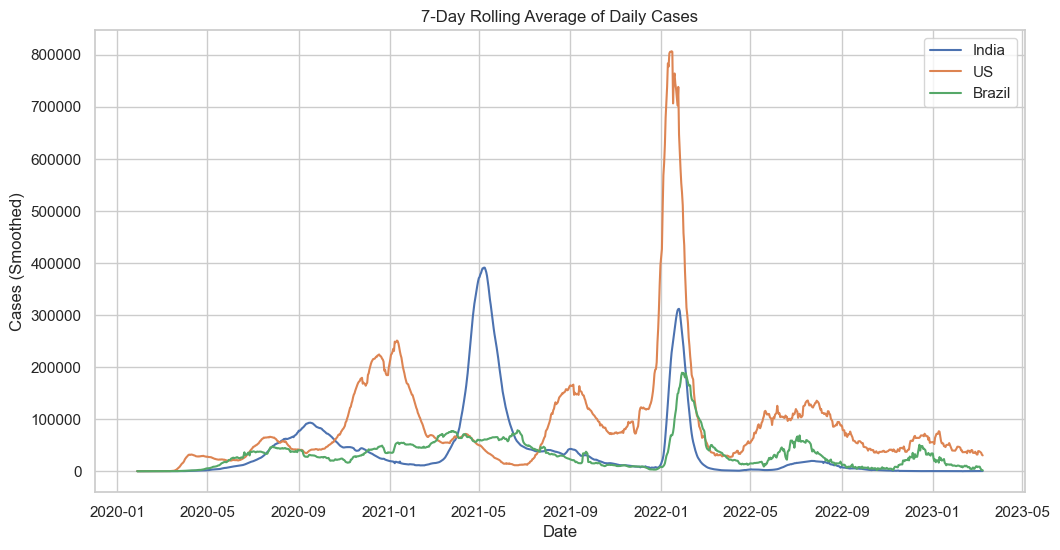

In [10]:
plt.figure(figsize=(12,6))
for country in countries:
    plt.plot(rolling_avg.index, rolling_avg[country], label=country)

plt.title("7-Day Rolling Average of Daily Cases")
plt.xlabel("Date")
plt.ylabel("Cases (Smoothed)")
plt.legend()
plt.savefig("rolling_average.png")
plt.show()

In [11]:
peaks_dict = {}

for country in countries:
    peaks, _ = find_peaks(rolling_avg[country].dropna(), distance=30)
    peaks_dict[country] = rolling_avg[country].iloc[peaks]

print("Detected Peaks:\n")
for country, peak_values in peaks_dict.items():
    print(f"\n{country}:\n", peak_values.head())

Detected Peaks:


India:
 2020-01-29        0.000000
2020-03-04        3.571429
2020-04-19     1201.428571
2020-05-19     4597.571429
2020-08-08    57469.571429
Name: India, dtype: float64

US:
 2020-01-31        0.857143
2020-04-04    28131.857143
2020-05-14    22662.142857
2020-07-18    64774.571429
2020-09-18    41468.571429
Name: US, dtype: float64

Brazil:
 2020-02-29        0.285714
2020-04-15     1735.714286
2020-05-18    12253.428571
2020-06-22    31629.428571
2020-07-22    37613.714286
Name: Brazil, dtype: float64


In [15]:
growth_rate = daily_cases.pct_change().rolling(7).mean()
growth_rate.tail()

Country/Region,India,US,Brazil
2023-03-05,0.074832,1.166371,NaN
2023-03-06,0.079561,-0.668294,NaN
2023-03-07,0.051768,-0.443513,NaN
2023-03-08,0.058327,-0.477616,NaN
2023-03-09,0.073324,-0.462547,NaN


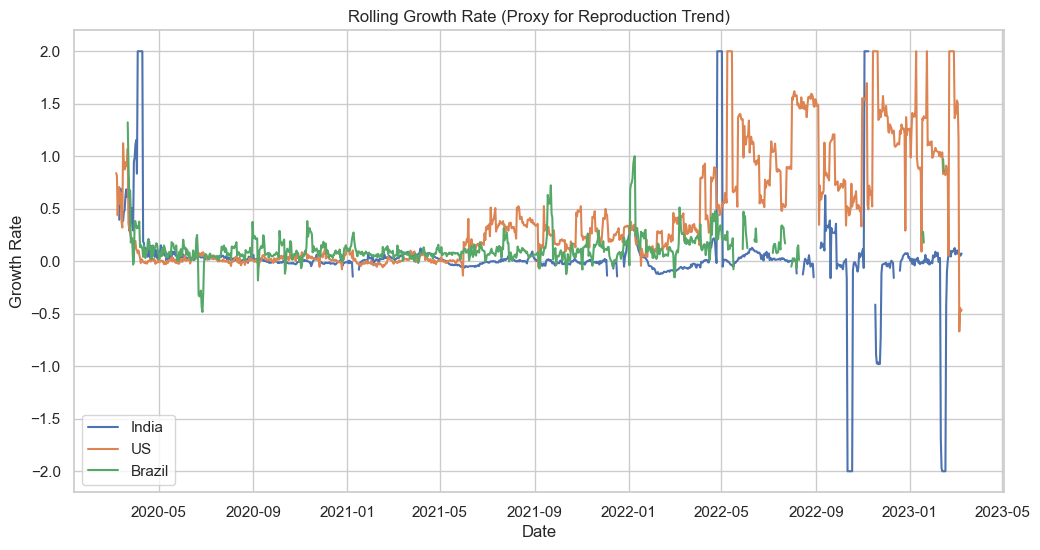

In [19]:
plt.figure(figsize=(12,6))
for country in countries:
    plt.plot(growth_rate.index, growth_rate[country], label=country)

plt.title("Rolling Growth Rate (Proxy for Reproduction Trend)")
plt.xlabel("Date")
plt.ylabel("Growth Rate")
plt.legend()
plt.savefig("growth_rate.png")
plt.show()

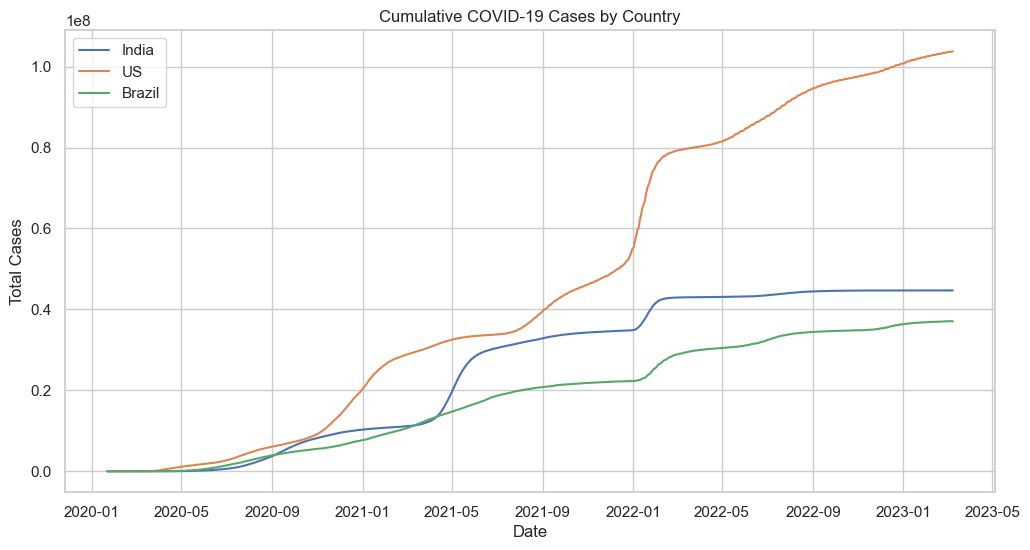

In [25]:
plt.figure(figsize=(12,6))

for country in countries:
    plt.plot(covid.index, covid[country], label=country)

plt.title("Cumulative COVID-19 Cases by Country")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.legend()

plt.savefig("cumulative_cases.png")
plt.show()

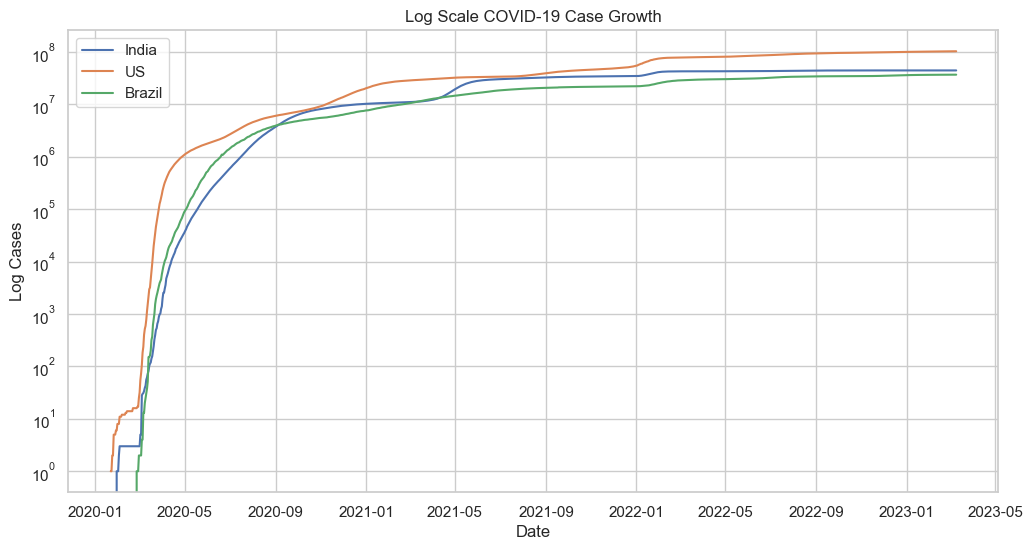

In [26]:
plt.figure(figsize=(12,6))

for country in countries:
    plt.plot(covid.index, covid[country], label=country)

plt.yscale("log")

plt.title("Log Scale COVID-19 Case Growth")
plt.xlabel("Date")
plt.ylabel("Log Cases")
plt.legend()

plt.savefig("log_case_growth.png")
plt.show()

C:\Users\arthi\AppData\Local\Temp\ipykernel_3744\3303051114.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_cases = daily_cases.resample("M").sum()


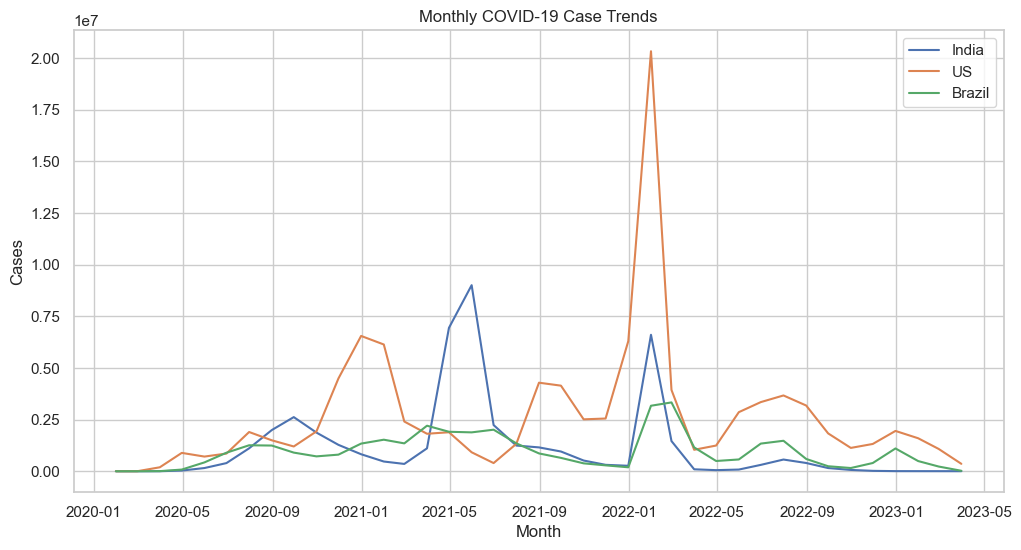

In [27]:
monthly_cases = daily_cases.resample("M").sum()

plt.figure(figsize=(12,6))

for country in countries:
    plt.plot(monthly_cases.index, monthly_cases[country], label=country)

plt.title("Monthly COVID-19 Case Trends")
plt.xlabel("Month")
plt.ylabel("Cases")
plt.legend()

plt.savefig("monthly_cases.png")
plt.show()

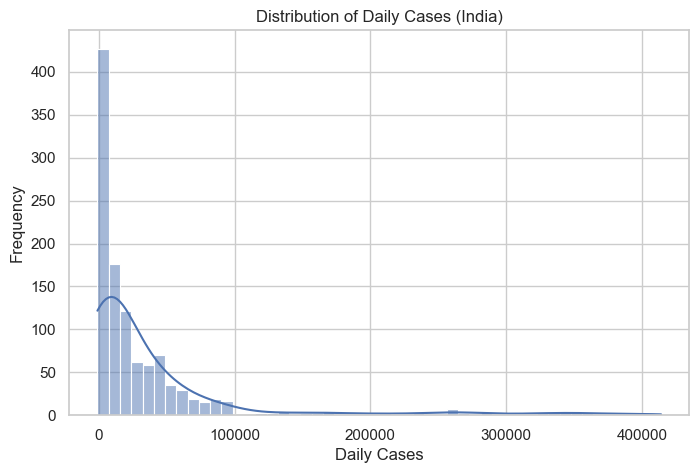

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(daily_cases["India"], bins=50, kde=True)

plt.title("Distribution of Daily Cases (India)")
plt.xlabel("Daily Cases")
plt.ylabel("Frequency")

plt.savefig("daily_distribution_india.png")
plt.show()

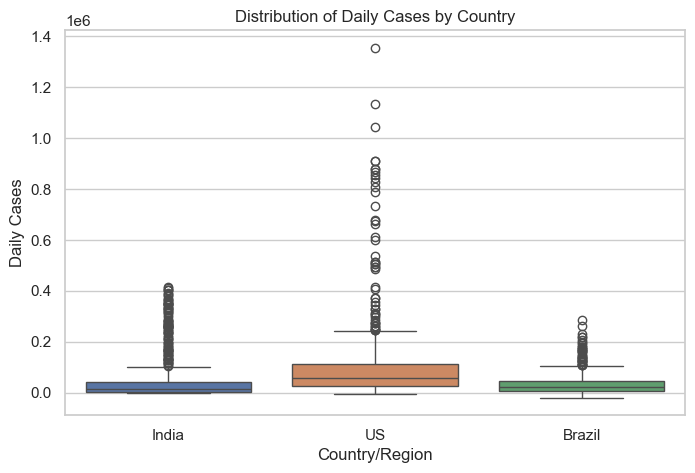

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(data=daily_cases[countries])

plt.title("Distribution of Daily Cases by Country")
plt.ylabel("Daily Cases")

plt.savefig("country_boxplot.png")
plt.show()

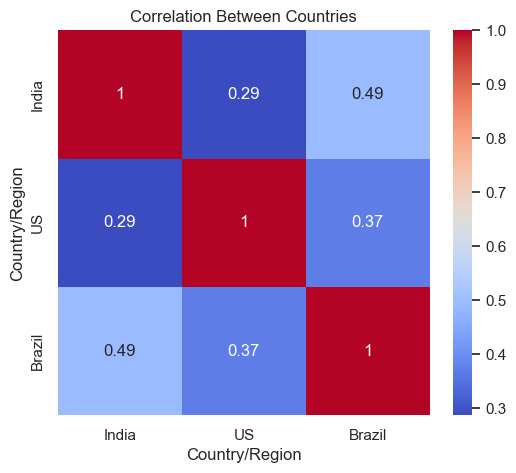

In [32]:
plt.figure(figsize=(6,5))

sns.heatmap(daily_cases[countries].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Between Countries")

plt.savefig("country_correlation.png")
plt.show()

In [33]:
doc = SimpleDocTemplate("COVID19_Analysis_Report.pdf")
elements = []
styles = getSampleStyleSheet()

elements.append(Paragraph("<b>COVID-19 Data Analysis Report</b>", styles["Title"]))
elements.append(Spacer(1, 0.3 * inch))

summary_text = """
Key Conclusions:
1. Clear multi-wave patterns observed in all countries.
2. Rolling averages smooth daily reporting noise effectively.
3. Peaks correspond to major outbreak waves.
4. Growth rate trends indicate reproduction pattern changes.
5. Countries show different wave timing and intensity.
"""

elements.append(Paragraph(summary_text, styles["Normal"]))
elements.append(Spacer(1, 0.5 * inch))

for image_file in ["daily_cases_comparison.png",
                   "rolling_average.png",
                   "growth_rate.png"]:
    if os.path.exists(image_file):
        elements.append(Image(image_file, width=5*inch, height=3*inch))
        elements.append(Spacer(1, 0.3 * inch))

doc.build(elements)

print("PDF Report Generated Successfully!")

PDF Report Generated Successfully!
